In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
TEST_PATH = r"E:\Casting defect classification framework\Dataset\CNN test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [3]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Classes:", test_generator.class_indices)

Found 20 images belonging to 2 classes.
Classes: {'Defective': 0, 'ok': 1}


In [4]:
cnn_model = load_model("E:\Casting defect classification framework\cnn_model.h5")

mobilenet_model = load_model("E:\Casting defect classification framework\mobilenet_model.h5")

print("Both models loaded successfully.")

Both models loaded successfully.


In [5]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_generator)

print("\nCustom CNN Results")
print("------------------------")
print(f"Loss     : {cnn_loss:.4f}")
print(f"Accuracy : {cnn_accuracy*100:.2f}%")

1/1 [==============================] - 1s 811ms/step - loss: 9.3557 - accuracy: 0.7000

Custom CNN Results
------------------------
Loss     : 9.3557
Accuracy : 70.00%


In [6]:
test_generator.reset()

cnn_predictions = cnn_model.predict(test_generator)

cnn_predicted = (cnn_predictions > 0.5).astype(int).flatten()

true_classes = test_generator.classes

1/1 [==============================] - 1s 777ms/step


In [7]:
print("CUSTOM CNN PERFORMANCE")
print("="*50)

print("Accuracy :",accuracy_score(true_classes,cnn_predicted))
print("Precision:",precision_score(true_classes,cnn_predicted))
print("Recall   :",recall_score(true_classes,cnn_predicted))
print("F1 Score :",f1_score(true_classes,cnn_predicted))

CUSTOM CNN PERFORMANCE
Accuracy : 0.7
Precision: 0.6666666666666666
Recall   : 0.5
F1 Score : 0.5714285714285714


In [8]:
print(classification_report(
    true_classes,
    cnn_predicted,
    target_names=['Defective','OK']
))

              precision    recall  f1-score   support

   Defective       0.71      0.83      0.77        12
          OK       0.67      0.50      0.57         8

    accuracy                           0.70        20
   macro avg       0.69      0.67      0.67        20
weighted avg       0.70      0.70      0.69        20



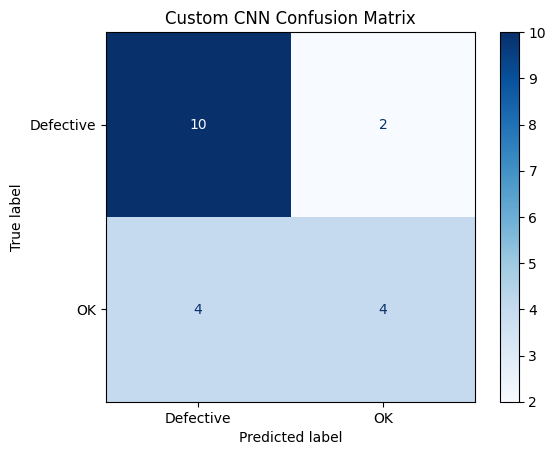

In [9]:
cm = confusion_matrix(true_classes,cnn_predicted)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Defective','OK']
)

disp.plot(cmap="Blues")

plt.title("Custom CNN Confusion Matrix")
plt.show()

In [10]:
mobilenet_loss,mobilenet_accuracy = mobilenet_model.evaluate(test_generator)

print("\nMobileNetV2 Results")
print("------------------------")
print(f"Loss     : {mobilenet_loss:.4f}")
print(f"Accuracy : {mobilenet_accuracy*100:.2f}%")

1/1 [==============================] - 3s 3s/step - loss: 1.2658 - accuracy: 0.8000

MobileNetV2 Results
------------------------
Loss     : 1.2658
Accuracy : 80.00%


In [11]:
test_generator.reset()

mobile_predictions = mobilenet_model.predict(test_generator)

mobile_predicted = (mobile_predictions>0.5).astype(int).flatten()

1/1 [==============================] - 2s 2s/step


In [12]:
print("MOBILENETV2 PERFORMANCE")
print("="*50)

print("Accuracy :",accuracy_score(true_classes,mobile_predicted))
print("Precision:",precision_score(true_classes,mobile_predicted))
print("Recall   :",recall_score(true_classes,mobile_predicted))
print("F1 Score :",f1_score(true_classes,mobile_predicted))

MOBILENETV2 PERFORMANCE
Accuracy : 0.8
Precision: 0.8333333333333334
Recall   : 0.625
F1 Score : 0.7142857142857143


In [13]:
print(classification_report(
    true_classes,
    mobile_predicted,
    target_names=['Defective','OK']
))

              precision    recall  f1-score   support

   Defective       0.79      0.92      0.85        12
          OK       0.83      0.62      0.71         8

    accuracy                           0.80        20
   macro avg       0.81      0.77      0.78        20
weighted avg       0.80      0.80      0.79        20



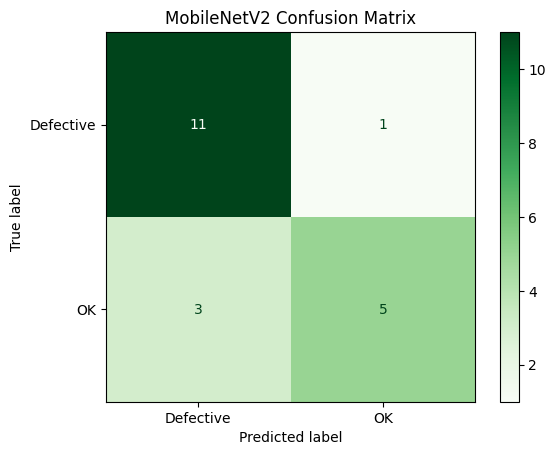

In [14]:
cm = confusion_matrix(true_classes,mobile_predicted)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Defective','OK']
)

disp.plot(cmap="Greens")

plt.title("MobileNetV2 Confusion Matrix")
plt.show()

In [15]:
print("="*60)
print("MODEL COMPARISON")
print("="*60)

print(f"Custom CNN Accuracy     : {cnn_accuracy*100:.2f}%")
print(f"MobileNetV2 Accuracy    : {mobilenet_accuracy*100:.2f}%")

print(f"Custom CNN Loss         : {cnn_loss:.4f}")
print(f"MobileNetV2 Loss        : {mobilenet_loss:.4f}")


MODEL COMPARISON
Custom CNN Accuracy     : 70.00%
MobileNetV2 Accuracy    : 80.00%
Custom CNN Loss         : 9.3557
MobileNetV2 Loss        : 1.2658


In [16]:
#generate loss curve and accuracy curve for both models


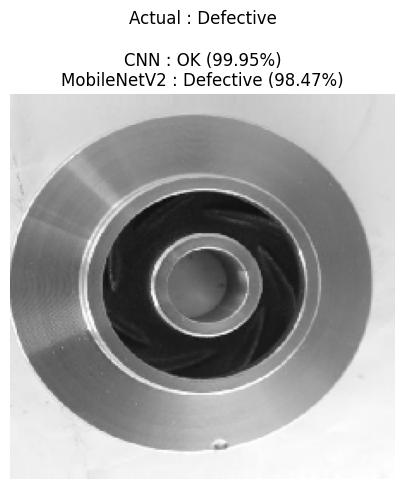

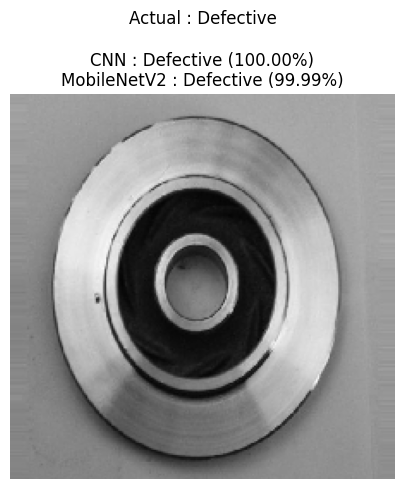

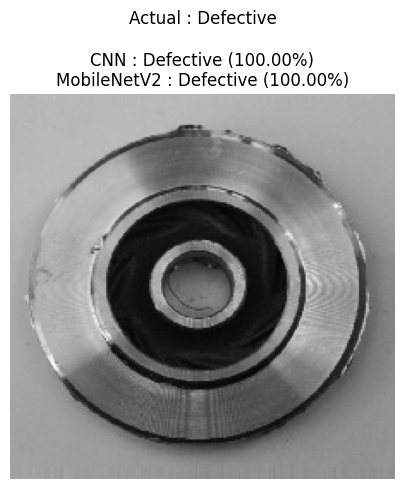

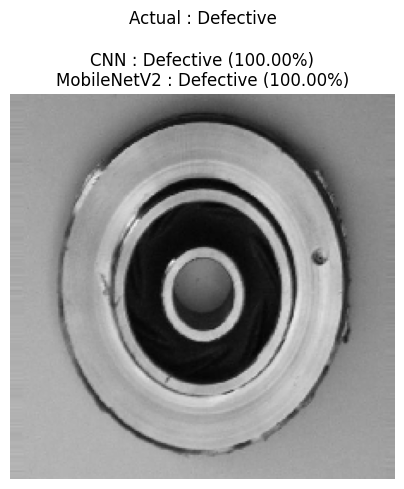

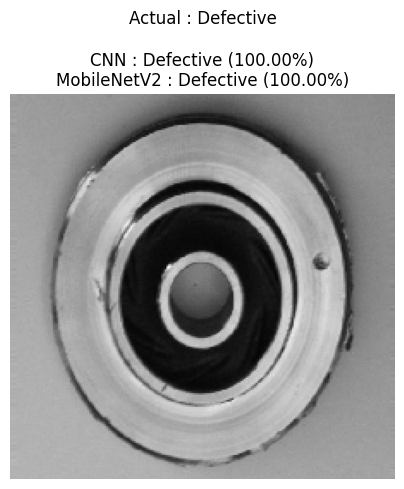

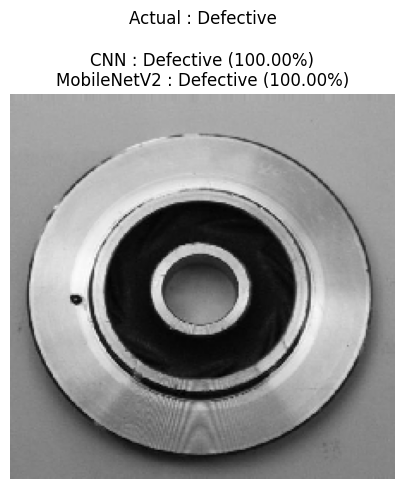

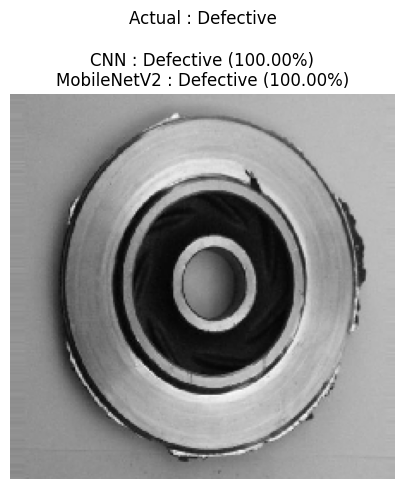

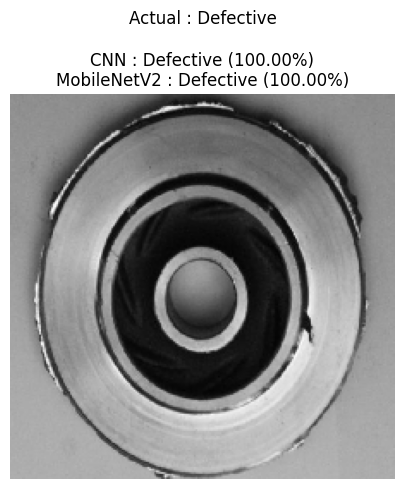

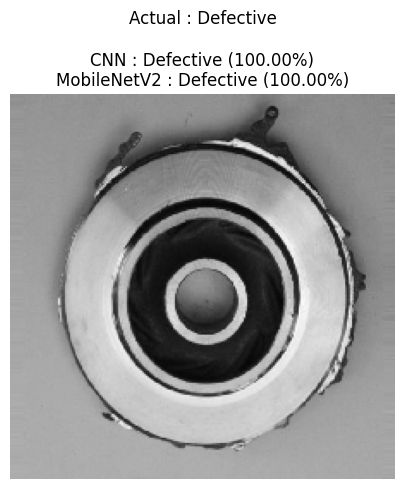

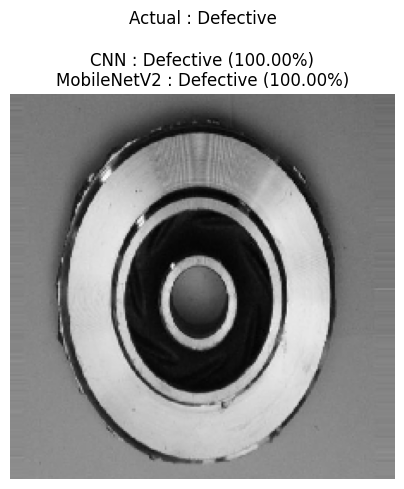

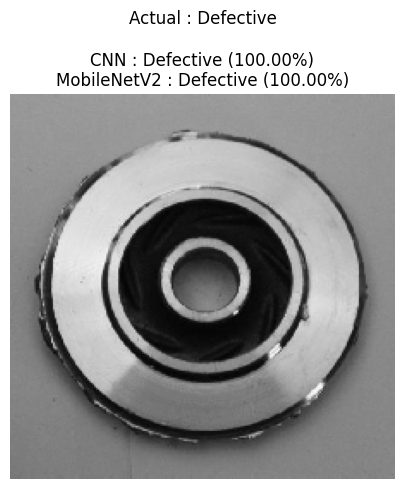

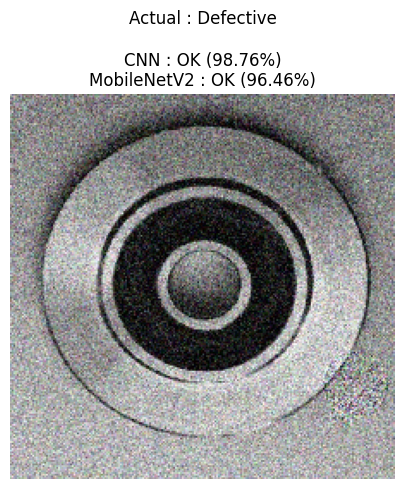

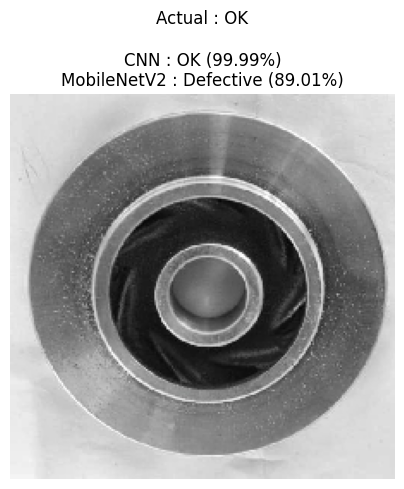

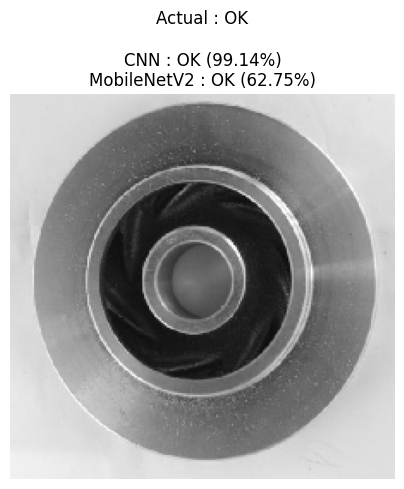

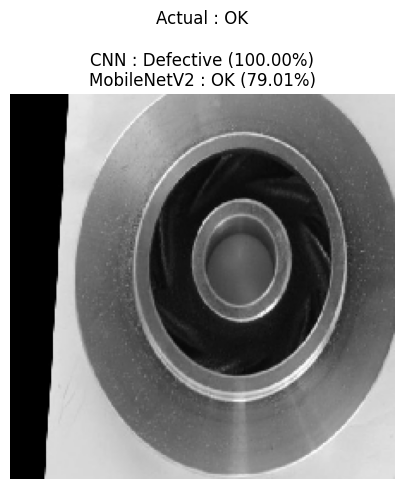

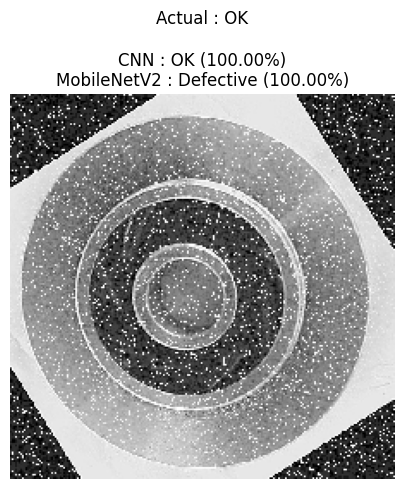

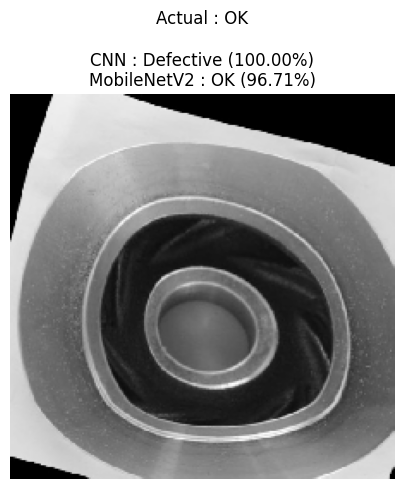

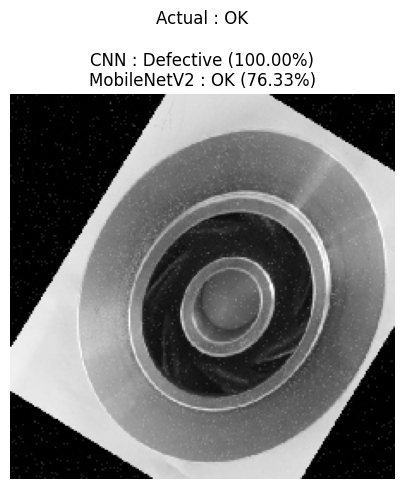

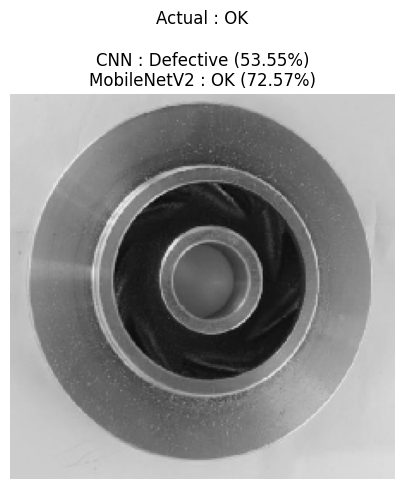

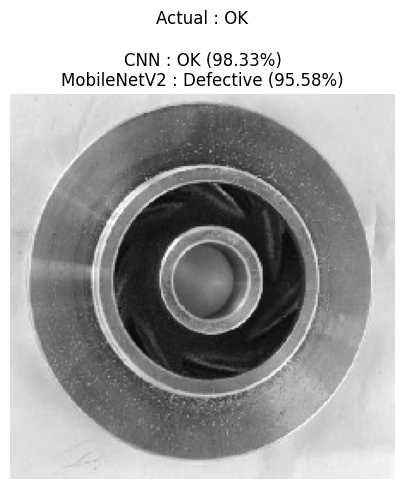

In [17]:
class_names = ['Defective','OK']

for class_name in class_names:

    folder = os.path.join(TEST_PATH,class_name)

    for filename in os.listdir(folder):

        image_path = os.path.join(folder,filename)

        from tensorflow.keras.preprocessing import image

        img = image.load_img(image_path,target_size=(224,224))

        x = image.img_to_array(img)/255.0
        x = np.expand_dims(x,axis=0)

        cnn_pred = cnn_model.predict(x,verbose=0)
        mobile_pred = mobilenet_model.predict(x,verbose=0)

        cnn_class = class_names[int(cnn_pred[0][0]>0.5)]
        mobile_class = class_names[int(mobile_pred[0][0]>0.5)]

        cnn_conf = cnn_pred[0][0] if cnn_class=="OK" else 1-cnn_pred[0][0]
        mobile_conf = mobile_pred[0][0] if mobile_class=="OK" else 1-mobile_pred[0][0]

        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"Actual : {class_name}\n\n"
            f"CNN : {cnn_class} ({cnn_conf*100:.2f}%)\n"
            f"MobileNetV2 : {mobile_class} ({mobile_conf*100:.2f}%)"
        )

        plt.show()

In [18]:

TEST_PATH = r"E:\Casting defect classification framework\Dataset\CNN test"
IMG_SIZE = (224, 224)
class_names = ["Defective", "OK"]

model = cnn_model          

images = []

for actual_class in class_names:

    folder = os.path.join(TEST_PATH, actual_class)

    for filename in sorted(os.listdir(folder)):

        img_path = os.path.join(folder, filename)

        img = image.load_img(img_path, target_size=IMG_SIZE)

        x = image.img_to_array(img)
        x = x / 255.0
        x = np.expand_dims(x, axis=0)

        prediction = model.predict(x, verbose=0)

        probability = prediction[0][0]

        if probability >= 0.5:
            predicted = "OK"
            confidence = probability * 100
        else:
            predicted = "Defective"
            confidence = (1 - probability) * 100

        status = "Correct" if predicted == actual_class else "Wrong"

        images.append({
            "image": img,
            "actual": actual_class,
            "predicted": predicted,
            "confidence": confidence,
            "status": status
        })

cols = 5
rows = math.ceil(len(images) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, item in enumerate(images):

    axes[i].imshow(item["image"])
    axes[i].axis("off")

    title_color = "green" if item["status"] == "Correct" else "red"

    axes[i].set_title(
        f"Actual : {item['actual']}\n"
        f"Predicted : {item['predicted']}\n"
        f"Confidence : {item['confidence']:.2f}%\n"
        f"Status : {item['status']}",
        fontsize=8,
        color=title_color
    )

# Hide empty plots
for j in range(len(images), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Casting Defect Detection - Prediction Results\n",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

# Save as PDF
plt.savefig(
    r"E:\Casting defect classification framework\Casting_Defect_Predictions.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nPDF saved successfully!")

NameError: name 'math' is not defined